In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from typing import Optional, Tuple
from tqdm import tqdm

plt.style.use("seaborn-v0_8")
plt.rcParams.update({"font.size": 11, "figure.dpi": 140})

from simulation.make_dataset import make_dataset
from simulation.simulator import *
from constants import *
from ml.profile_inversion import ProfileInversion

In [3]:
# Fixed values for plotting
d_val_m = 40e-9
tau = 12 * 3600.
phys = PhysicsConstants(d_val_m= d_val_m, tau= tau)
params = SimulationParameters()
D_true = D_N_from_dim(phys)
P_true = P_N_from_dim(phys)
A_true = (D_true * params.t_f) / (params.R_T ** 2)
G_true = (P_true * params.R_T) / D_true

# Make full-size datasets for different noise levels
noise_levels = [0.00, 0.02, 0.05, 0.2]
data_params = DatasetParameters(
    d_val_m= np.array([40e-9]),
    tau= np.array([tau]),
    save= False,
    noise_level= noise_levels[0]
)
datasets = []
for noise in noise_levels:
    data_params.noise_level = noise
    dataset = make_dataset(phys, params, data_params)
    dataset["CN"] = dataset["CN"][0,0]; dataset["CF"] = dataset["CF"][0,0]; dataset["CI"] = dataset["CI"][0,0]
    datasets.append(dataset)

d_val_m: 100%|██████████| 1/1 [00:00<00:00,  2.45it/s]


In [4]:
inv_params = InversionParameters()
inv = ProfileInversion(phys, params, inv_params)
A_grid = np.exp(np.linspace(np.log(inv_params.A_low), np.log(inv_params.A_high), 25))
G_grid = np.exp(np.linspace(np.log(inv_params.G_low), np.log(inv_params.G_high), 25))

In [ ]:
def plot_loss_surface(
        L_surf: np.ndarray,
        A_grid: np.ndarray,
        Gamma_grid: np.ndarray,
        A_true: float,
        Gamma_true: float,
        A_est: float,
        Gamma_est: float,
        d_nm: int,
        fig: Optional[plt.Figure] = None,
        ax: Optional[plt.Axes] = None,
        norm: Optional[colors.Normalize] = None,
        show_colorbar: bool = True,
        title: Optional[str] = None,
    ) -> Tuple[plt.Figure, plt.Axes]:

        if fig is None or ax is None:
            fig, ax = plt.subplots(figsize=(6.5, 5.0))

        L_min_pos = L_surf[L_surf > 0].min() if np.any(L_surf > 0) else 1e-30
        L_plot = np.where(L_surf > 0, L_surf, L_min_pos)

        log_L = np.log10(L_plot).T
        x = np.log10(A_grid)
        y = np.log10(Gamma_grid)

        if norm is None:
            norm = colors.Normalize(vmin=log_L.min(), vmax=log_L.max())

        pcm = ax.pcolormesh(
            x,
            y,
            log_L,
            cmap="RdYlBu_r",
            shading="auto",
            norm=norm,
        )

        if show_colorbar:
            cb = fig.colorbar(pcm, ax=ax)
            cb.set_label(r"$\log_{10}\,\mathcal{L}(A,\,\Gamma)$")

        ax.contour(
            x,
            y,
            log_L,
            levels=20,
            colors="k",
            linewidths=0.5,
            alpha=0.35,
        )

        ax.scatter(
            np.log10(A_true), np.log10(Gamma_true),
            c="cyan", s=120, marker="*", zorder=6,
            edgecolors="k", linewidths=0.8,
            label="True $(A, \Gamma)$",
        )
        ax.scatter(
            np.log10(A_est), np.log10(Gamma_est),
            c="red", s=80, marker="x", linewidths=2.5, zorder=6,
            label="Recovered",
        )

        ax.set_xlabel(r"$\log_{10}(A)$")
        ax.set_ylabel(r"$\log_{10}(\Gamma)$")
        if title is not None:
            ax.set_title(title)
        ax.legend(fontsize=9, loc="upper right")
        ax.grid(alpha=0.25)
        return fig, ax

In [47]:
inv_results = []
L_surfaces = []
for idx in range(len(noise_levels)):
    inv_results.append(inv.invert(datasets[idx]))
    L_surfaces.append(inv.loss_surface(datasets[idx], A_grid, G_grid))

100%|██████████| 25/25 [13:35<00:00, 32.61s/it] 


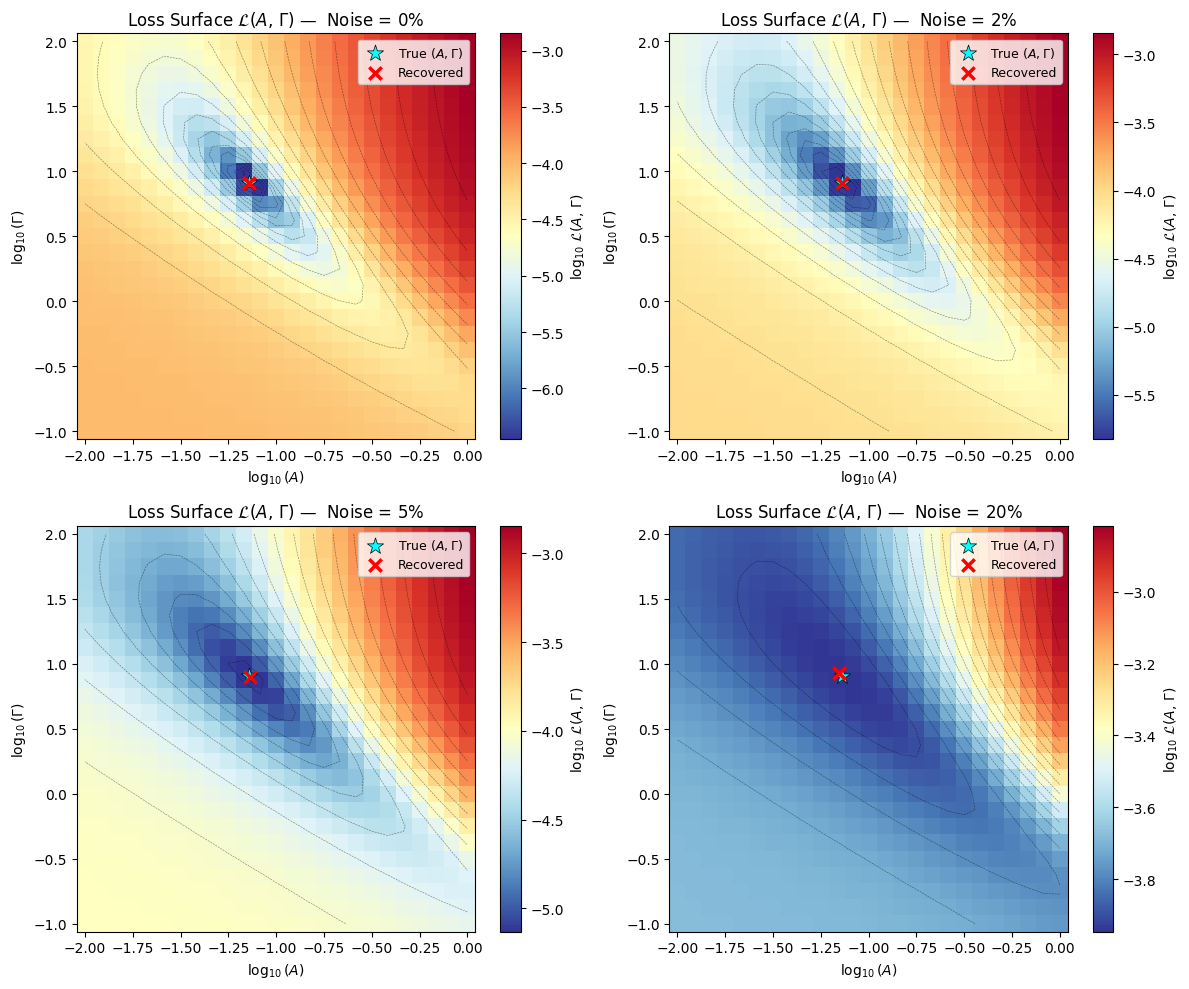

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11), constrained_layout=True)

log_L_values = []
for L_surf in L_surfaces:
    L_min_pos = L_surf[L_surf > 0].min() if np.any(L_surf > 0) else 1e-30
    L_plot = np.where(L_surf > 0, L_surf, L_min_pos)
    log_L_values.append(np.log10(L_plot))

common_norm = colors.Normalize(
    vmin=min(log_L.min() for log_L in log_L_values),
    vmax=max(log_L.max() for log_L in log_L_values),
)

for ax, noise, L_surf, inv_res in zip(axes.flat, noise_levels, L_surfaces, inv_results):
    plot_loss_surface(
        L_surf,
        A_grid,
        G_grid,
        A_true,
        G_true,
        inv_res["A_est"],
        inv_res["G_est"],
        int(d_val_m * 1e9),
        fig=fig,
        ax=ax,
        norm=common_norm,
        show_colorbar=False,
        title=f"Noise = {int(100 * noise)}%",
    )

cbar = fig.colorbar(axes[0, 0].collections[0], ax=axes.ravel().tolist(), location="right", shrink=0.88)
cbar.set_label(r"$\log_{10}\,\mathcal{L}(A,\,\Gamma)$")
fig.suptitle("Loss surface comparison over noise levels", y=1.02, fontsize=14)

In [6]:
data_num_obs = datasets[2] # 5% noise
num_of_obs = [1, 2, 4, 8, 20, 50, 100]
strides = [len(data_num_obs["CN"]) // num for num in num_of_obs]

inv_params = InversionParameters()
inv = ProfileInversion(phys, params, inv_params)

In [7]:
inv_num_results = []
for stride in tqdm(strides):
    data_stride = {"r": data_num_obs["r"], "t_out": data_num_obs["t_out"][::stride], "CN": data_num_obs["CN"][::stride, :]}
    inv_num_results.append(inv.invert(data_stride))

100%|██████████| 7/7 [13:00<00:00, 111.44s/it]


In [20]:
A_est = np.array([res["A_est"] for res in inv_num_results])
G_est = np.array([res["G_est"] for res in inv_num_results])

In [21]:
A_rel = np.abs(A_est - A_true) / A_true
G_rel = np.abs(G_est - G_true) / G_true

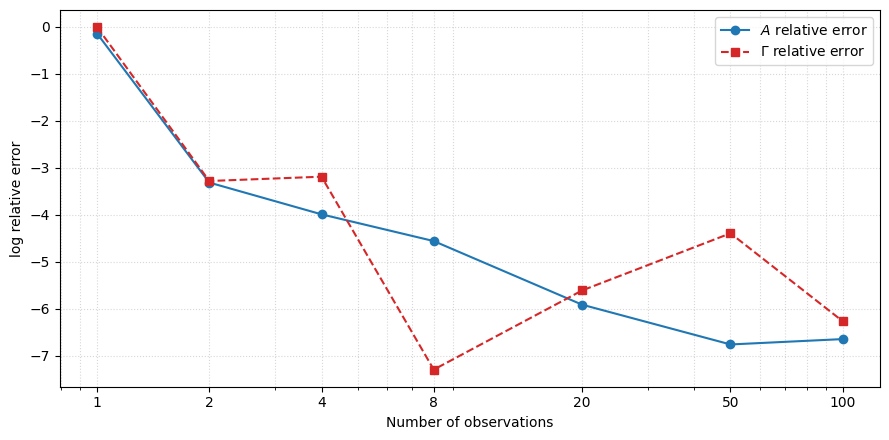

In [25]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(num_of_obs, np.log(A_rel), marker='o', linestyle='-', color='tab:blue', label=r'$A$ relative error')
ax.plot(num_of_obs, np.log(G_rel), marker='s', linestyle='--', color='tab:red', label=r'$\Gamma$ relative error')
ax.set_xscale('log')
ax.set_xticks(num_of_obs)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel('Number of observations')
ax.set_ylabel('log relative error')
ax.grid(True, which='both', linestyle=':', alpha=0.5)
ax.legend()
fig.tight_layout()